# Project Title
Customer Purchase Analysis using Python

# Tools
•	Python 
•	Pandas 
•	NumPy 
•	Matplotlib 
•	Seaborn 


# Project Objective : Analyze customer transaction data to

• Identify Customer Purchase Behavior

• Identify High Value Customers 

• Customer Segmentation 

• Purchase Frequency Analysis 

• Revenue Contribution Analysis 

• Generate Business Recommendations

# Objective : Analyze sales data

Revenue Analysis

Profit Analysis

Customer Growth Analysis

Regional Performance Analysis

Top Performing Products Identification

Business Insights Generation

# Step 1: Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# Step 2: Load Dataset

In [78]:
df = pd.read_csv("customer_purchase.csv")

df.head()



,Customer_ID,Order_ID,Purchase_Date,Product,Quantity,Sales
0,C167,5000,2025-01-01,Monitor,3,65206
1,C118,5001,2025-01-02,Printer,3,48203
2,C158,5002,2025-01-03,Mouse,2,67632
3,C148,5003,2025-01-04,Mobile,1,35710
4,C197,5004,2025-01-05,Mobile,4,37662


# Step 3: Dataset Information

In [79]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    300 non-null    object
 1   Order_ID       300 non-null    int64 
 2   Purchase_Date  300 non-null    object
 3   Product        300 non-null    object
 4   Quantity       300 non-null    int64 
 5   Sales          300 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 14.2+ KB


,Order_ID,Quantity,Sales
count,300.000000,300.000000,300.000000
mean,5149.500000,2.623333,41813.520000
std,86.746758,1.154367,23292.806202
min,5000.000000,1.000000,2389.000000
25%,5074.750000,2.000000,21099.500000
50%,5149.500000,3.000000,41510.000000
75%,5224.250000,4.000000,63421.250000
max,5299.000000,4.000000,79841.000000


# Questions

1.	Total Transactions?
  
2.	Total Customers?

  
3.	Average Purchase Amount?

  
4.	Maximum Purchase Amount? 



# Lab 4: Data Cleaning 
 Missing Value Check

In [80]:
df.isnull().sum()
df.dropna(inplace=True)

# Duplicate Records

In [81]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Step 5: Total Revenue Analysis

In [82]:
total_revenue = df['Sales'].sum()

print(total_revenue)


12544056


# Lab 6: Customer Purchase Frequency

# Number of Purchases per Customer

In [83]:
purchase_frequency = df.groupby('Customer_ID')['Order_ID'].count()

purchase_frequency.head()


Customer_ID
C101    2
C102    4
C103    4
C104    4
C105    4
Name: Order_ID, dtype: int64

# Top Customers

In [84]:
top_customers = purchase_frequency.sort_values(ascending=False).head(10)

top_customers


Customer_ID
C121    8
C128    8
C185    8
C117    7
C158    6
C156    6
C141    6
C182    6
C139    5
C148    5
Name: Order_ID, dtype: int64

# Visualization

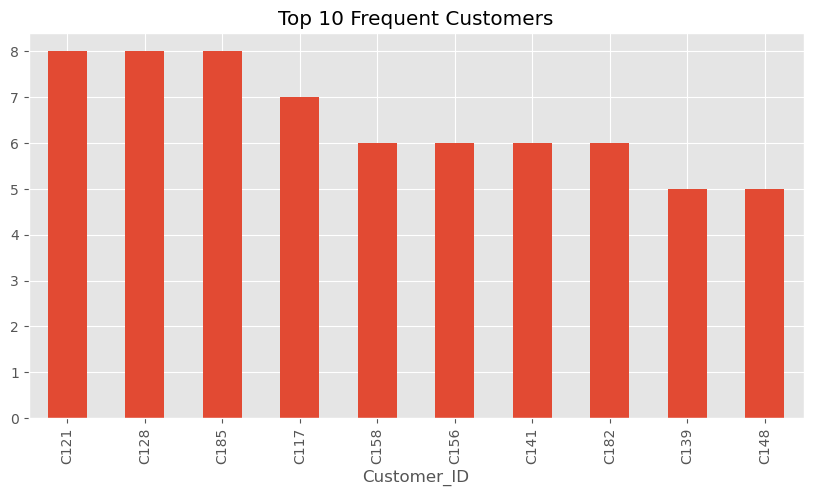

In [85]:
top_customers.plot(kind='bar',figsize=(10,5))

plt.title("Top 10 Frequent Customers")
plt.show()


# Lab 7: Customer Spending Analysis

In [86]:
customer_sales = df.groupby('Customer_ID')['Sales'].sum()
customer_sales

Customer_ID
C101     60995
C102    238368
C103    300063
C104    129306
C105    120201
         ...  
C196     29631
C197    141908
C198    136756
C199    100825
C200    143662
Name: Sales, Length: 98, dtype: int64

# Highest Spending Customers

In [87]:
top_spenders = customer_sales.sort_values(ascending=False).head(10)

top_spenders


Customer_ID
C121    401617
C128    343198
C182    307759
C103    300063
C156    294138
C158    288912
C185    277175
C155    267585
C162    253347
C148    248582
Name: Sales, dtype: int64

# Visualization

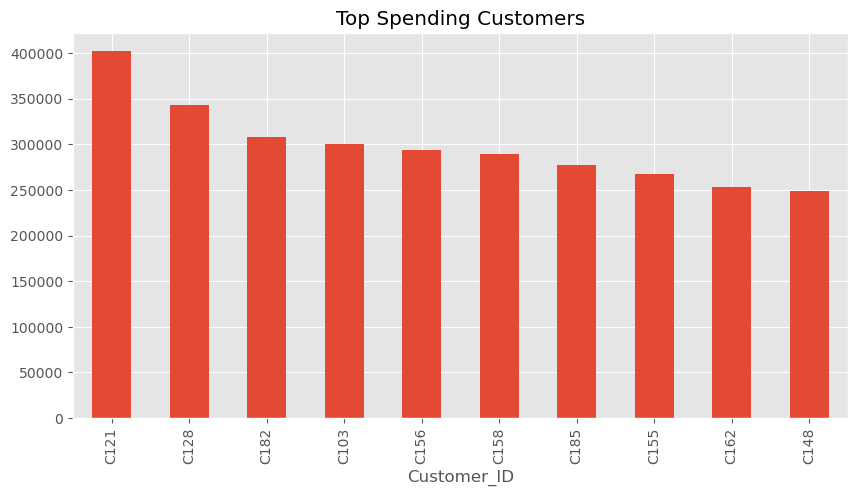

In [88]:
top_spenders.plot(kind='bar',figsize=(10,5))

plt.title("Top Spending Customers")
plt.show()
 

# Lab 8: Average Purchase Value

In [89]:
avg_purchase = df.groupby('Customer_ID')['Sales'].mean()

avg_purchase.head()


Customer_ID
C101    30497.50
C102    59592.00
C103    75015.75
C104    32326.50
C105    30050.25
Name: Sales, dtype: float64

# Lab 9: Product Preference Analysis

In [90]:
product_sales = df.groupby('Product')['Sales'].sum()

product_sales


Product
Keyboard    1556869
Laptop      2048970
Mobile      1964496
Monitor     1399922
Mouse       1972223
Printer     1893932
Tablet      1707644
Name: Sales, dtype: int64

# Visualization

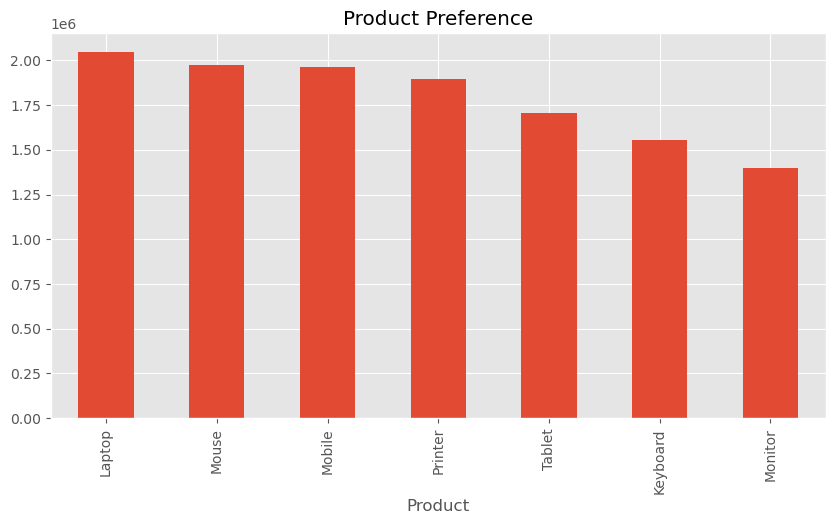

In [91]:
product_sales.sort_values(ascending=False).plot(kind='bar',figsize=(10,5))

plt.title("Product Preference")
plt.show()


# Lab 10: Customer Segmentation

# Segment Based on Total Spending

In [92]:
customer_sales = customer_sales.reset_index()

customer_sales.columns = ['Customer_ID','Total_Spending']

# Create Segments

In [93]:
customer_sales['Segment'] = pd.cut(
customer_sales['Total_Spending'],
bins=[0,50000,150000,500000],
labels=['Low','Medium','High']
)

customer_sales.head()


,Customer_ID,Total_Spending,Segment
0,C101,60995,Medium
1,C102,238368,High
2,C103,300063,High
3,C104,129306,Medium
4,C105,120201,Medium


# Segment Distribution

In [94]:
customer_sales['Segment'].value_counts()

Segment
Medium    62
High      26
Low       10
Name: count, dtype: int64

# Visualization

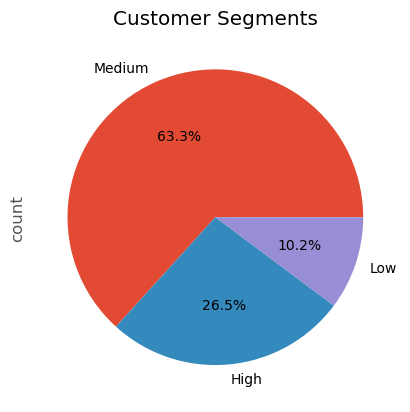

In [95]:
customer_sales['Segment'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.title("Customer Segments")
plt.show()


# Lab 11: Monthly Purchase Trend

In [96]:
df['Purchase_Date'] = pd.to_datetime(
df['Purchase_Date']
)

monthly_sales = df.groupby(
df['Purchase_Date'].dt.month
)['Sales'].sum()


# Visualization

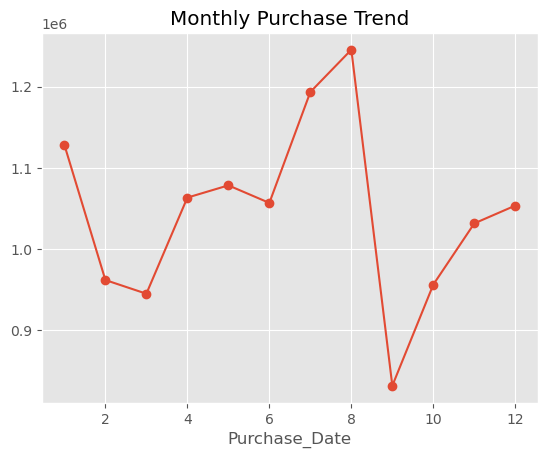

In [97]:
monthly_sales.plot(
kind='line',
marker='o'
)

plt.title("Monthly Purchase Trend")
plt.show()


# Lab 12: RFM Analysis (Advanced)

# Recency

In [98]:
latest_date = df['Purchase_Date'].max()
latest_date 

recency = df.groupby('Customer_ID')['Purchase_Date'].max()
recency 

recency = (latest_date - recency).dt.days
recency

Customer_ID
C101    109
C102    134
C103     63
C104     50
C105     39
       ... 
C196      9
C197    228
C198    133
C199     49
C200     87
Name: Purchase_Date, Length: 98, dtype: int64

# Frequency

In [99]:
frequency = df.groupby('Customer_ID')['Order_ID'].count()
frequency

Customer_ID
C101    2
C102    4
C103    4
C104    4
C105    4
       ..
C196    1
C197    4
C198    2
C199    2
C200    3
Name: Order_ID, Length: 98, dtype: int64

# Monetary

In [100]:
monetary = df.groupby('Customer_ID')['Sales'].sum()
monetary 

Customer_ID
C101     60995
C102    238368
C103    300063
C104    129306
C105    120201
         ...  
C196     29631
C197    141908
C198    136756
C199    100825
C200    143662
Name: Sales, Length: 98, dtype: int64

# Create RFM Table

In [101]:
rfm = pd.DataFrame()

rfm['Recency'] = recency
rfm['Frequency'] = frequency
rfm['Monetary'] = monetary

rfm.head()


,Recency,Frequency,Monetary
Customer_ID,,,
C101,109,2,60995
C102,134,4,238368
C103,63,4,300063
C104,50,4,129306
C105,39,4,120201


# Lab 13: Correlation Analysis

In [102]:
corr = rfm.corr()

corr


,Recency,Frequency,Monetary
Recency,1.000000,-0.419819,-0.376452
Frequency,-0.419819,1.000000,0.872610
Monetary,-0.376452,0.872610,1.000000


# Heatmap

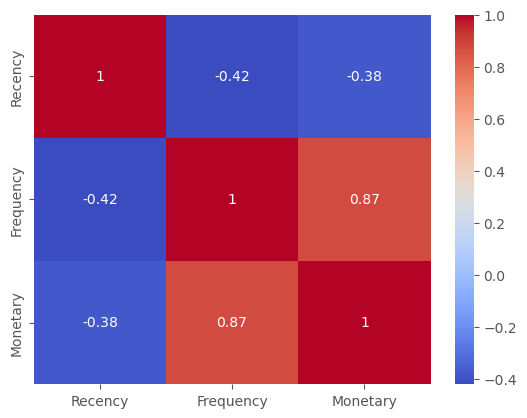

In [103]:
sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.show()


# Lab 14: KPI Dashboard

In [104]:
total_customers = df['Customer_ID'].nunique()

total_orders = df['Order_ID'].count()

total_revenue = df['Sales'].sum()

avg_order_value = df['Sales'].mean()
print("Customers:",total_customers)
print("Orders:",total_orders)
print("Revenue:",total_revenue)
print("Avg Order:",avg_order_value)


Customers: 98
Orders: 300
Revenue: 12544056
Avg Order: 41813.52


# Final Business Insights

In [105]:
Insight 1
Top 20% customers generate majority of revenue.
    
Insight 2
Certain products dominate customer purchases.
    
Insight 3
High-value customers should receive loyalty offers.
    
Insight 4
Low-frequency customers need retention campaigns.
    
Insight 5
Customer segmentation helps personalized marketing.


SyntaxError: invalid syntax (3333647378.py, line 1)